### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether they will accept the coupon if they are the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \\$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\\$20 - \\$50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

**1. Read in the `coupons.csv` file.**




In [2]:
data = pd.read_csv('data/coupons.csv')

In [3]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


**2. Investigate the dataset for missing or problematic data.**

In [4]:
data.isnull().sum()

destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

**Takeaway**

Using `isnull()` with `sum()` allows us to quickly determine how many values in each column are not set.

We can see that only the `car` column and the columns indicating how many times the user goes to each of the different venue types have null values, and are worth taking a closer look.

In [5]:
data.nunique()

destination              3
passanger                4
weather                  3
temperature              3
time                     5
coupon                   5
expiration               2
gender                   2
age                      8
maritalStatus            5
has_children             2
education                6
occupation              25
income                   9
car                      5
Bar                      5
CoffeeHouse              5
CarryAway                5
RestaurantLessThan20     5
Restaurant20To50         5
toCoupon_GEQ5min         1
toCoupon_GEQ15min        2
toCoupon_GEQ25min        2
direction_same           2
direction_opp            2
Y                        2
dtype: int64

**Takeaway**

Using `nunique()` allows us to get a high-level view of how many types of values exist for each column. We can see low counts for most categorical and binary columns as expected.

Columns worth investigating some more:
- **maritalStatus**: The data description only shows 4 categories, while we have a count of 5.
- **has_children**: The data description suggests a categorical column with 3 values, while the column name and value count suggests a binary column.
- **education**: The data description only shows 4 categories, while we have a count of 6.
- **toCoupon_GEQ5min**: This only has 1 listed value indicating that this has no bearing on the result.

**3. Decide what to do about your missing data -- drop, replace, other...**

In [6]:
data[['car', 'Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']].isnull().mean() * 100

car                     99.148534
Bar                      0.843582
CoffeeHouse              1.710817
CarryAway                1.190476
RestaurantLessThan20     1.024913
Restaurant20To50         1.490066
dtype: float64

**Takeaway**

By calling `mean()` on the result of `isnull()` for the columns with null values clearly shows that the `car` column contains more than 99% null values, and can be dropped.

In [7]:
# Helper function to print column value counts
def column_value_counts(cols):
    for col in cols:
        print(data[col].value_counts())
        print()

`column_value_counts` is a helper function to print value counts for the given columns.

In [8]:
column_value_counts(['maritalStatus', 'has_children', 'education', 'toCoupon_GEQ5min'])

maritalStatus
Married partner      5100
Single               4752
Unmarried partner    2186
Divorced              516
Widowed               130
Name: count, dtype: int64

has_children
0    7431
1    5253
Name: count, dtype: int64

education
Some college - no degree                  4351
Bachelors degree                          4335
Graduate degree (Masters or Doctorate)    1852
Associates degree                         1153
High School Graduate                       905
Some High School                            88
Name: count, dtype: int64

toCoupon_GEQ5min
1    12684
Name: count, dtype: int64



**Analysis**

- **maritalStatus**: There is one additional categorical value here that was not included in the description.
- **has_children**: This is indeed a binary value column indicating whether or not the user has children, not the categories mentioned in the data description.
- **education**: There are two additional categorical values here that were not included in the description.
- **toCoupon_GEQ5min**: This is always true, and can be dropped since its value has no bearing on whether or not the user accepts the offered coupon.

**Takeaway**

We can drop the `toCoupon_GEQ5min` column since it does not provide any value.

**4. What proportion of the total observations chose to accept the coupon?**

In [9]:
answer = data['Y'].mean()
print(f'{100 * answer: .2f}% of drivers chose to accept the coupon.')

 56.84% of drivers chose to accept the coupon.


**5. Use a bar plot to visualize the `coupon` column.**

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Restaurant(<20)'),
  Text(1, 0, 'Coffee House'),
  Text(2, 0, 'Carry out & Take away'),
  Text(3, 0, 'Bar'),
  Text(4, 0, 'Restaurant(20-50)')])

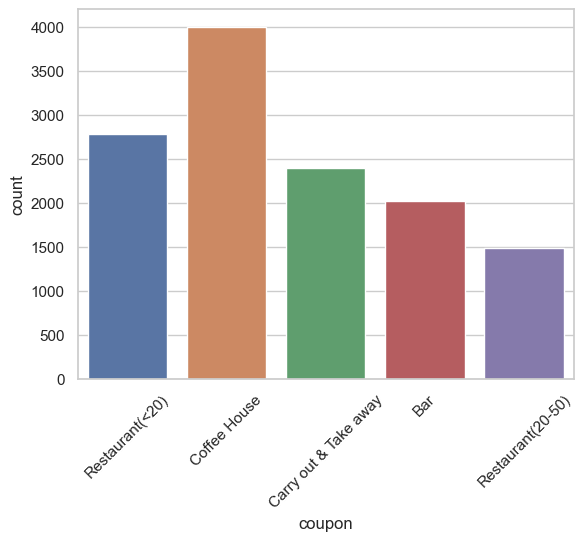

In [10]:
sns.set_theme(style="whitegrid")
sns.countplot(data=data, x='coupon', hue='coupon')
plt.xticks(rotation=45)

**6. Use a histogram to visualize the temperature column.**

array([[<Axes: title={'center': 'temperature'}>]], dtype=object)

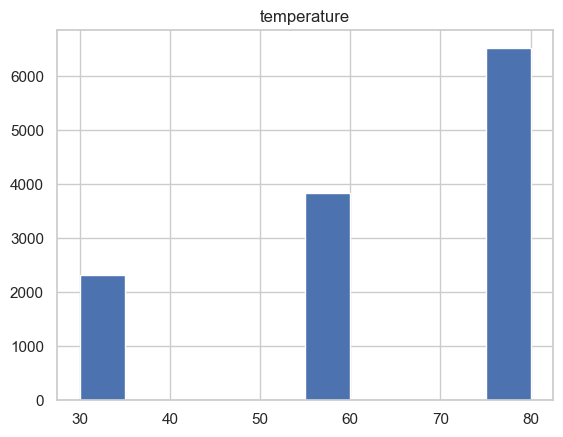

In [11]:
data.hist('temperature')

### Investigating the Bar Coupons

Now, we will lead you through an exploration of just the bar related coupons.  

**1. Create a new `DataFrame` that contains just the bar coupons.**


In [12]:
bar_coupons = data[data['coupon'] == 'Bar']
bar_coupons

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
9,No Urgent Place,Kid(s),Sunny,80,10AM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
13,Home,Alone,Sunny,55,6PM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,1,0,1
17,Work,Alone,Sunny,55,7AM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,1,0,1,0
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12663,No Urgent Place,Friend(s),Sunny,80,10PM,Bar,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12664,No Urgent Place,Friend(s),Sunny,55,10PM,Bar,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12667,No Urgent Place,Alone,Rainy,55,10AM,Bar,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12670,No Urgent Place,Partner,Rainy,55,6PM,Bar,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0


**2. What proportion of bar coupons were accepted?**


We will first create a helper function called `acceptance_rate` that takes a data frame as input and returns the  acceptance rate formatted as a percentage. This will help us avoid repeating formatting boilerplate.

In [13]:
# Helper function to compute and format acceptance rate as a percentage
def acceptance_rate(df):
    return f'{100 * df['Y'].mean(): .2f}%'

In [14]:
print(f'{acceptance_rate(bar_coupons)} of bar coupons were accepted')

 41.00% of bar coupons were accepted


**3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.**


In [15]:
three_or_fewer_categories = ['never', 'less1', '1~3']
three_or_fewer = bar_coupons.query('Bar in @three_or_fewer_categories')
four_or_more = bar_coupons.query('Bar not in @three_or_fewer_categories')
print(f'{acceptance_rate(three_or_fewer)} of users who went 3 or fewer times accepted the coupon.')
print(f'{acceptance_rate(four_or_more)} of users who went 4 or more times accepted the coupon.')

 37.06% of users who went 3 or fewer times accepted the coupon.
 73.18% of users who went 4 or more times accepted the coupon.


**4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?**


We will create a couple of helper functions:

- `print_coupon_acceptance` that filters a specified dataframe by the provided condition, and then prints out the formatted acceptance rate.
- `print_bar_coupon_acceptance` that applies `print_coupon_acceptance` to the `bar_coupons` dataframe.

In [16]:
# Helper function to print acceptance rate for drivers in the specified dataframe that match the given condition
def print_coupon_acceptance(df, condition, description):
    filtered = df[condition]
    print(f'{acceptance_rate(filtered)} of {description} accepted the coupon')

# Helper function to print acceptance rate for `bar_coupons` drivers matching the given condition
def print_bar_coupon_acceptance(condition, description):
    print_coupon_acceptance(bar_coupons, condition, description)

In [17]:
# drivers who go to the bar more than once a month
bar_more_than_once = bar_coupons['Bar'].isin(['4~8', 'gt8'])

# drivers who are over the age of 25
over_25 = bar_coupons['age'] > "25"

# combined condition
condition = bar_more_than_once & over_25

print_bar_coupon_acceptance(condition, 'drivers who go to a bar more than once a month and are over the age of 25')
print_bar_coupon_acceptance(~condition, 'other drivers')

 76.43% of drivers who go to a bar more than once a month and are over the age of 25 accepted the coupon
 38.36% of other drivers accepted the coupon


**Takeaway**

Drivers over the age of 25 who go to a bar more than once a month are about twice as likely to accept bar coupons when compated to other drivers.

**5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.**

In [18]:
# drivers who have non-kid passengers
non_kid_passengers = bar_coupons['passanger'] != 'Kid(s)'

# drivers whose occupation is not Farming Fishing & Forestry
not_fff = bar_coupons['occupation'] != 'Farming Fishing & Forestry'

# combined condition
condition = bar_more_than_once & non_kid_passengers & not_fff

print_bar_coupon_acceptance(condition, 'drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry')
print_bar_coupon_acceptance(~condition, 'other drivers')

 77.49% of drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry accepted the coupon
 37.19% of other drivers accepted the coupon


**Takeaway**

The difference is even more pronounced when looking at drivers matching the specified criteria as compared to drivers not matching the criteria.

**6. Compare the acceptance rates between those drivers who:**

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [19]:
# drivers who are not widowed
not_widowed = bar_coupons['maritalStatus'] != 'Widowed'

# drivers under the age of 30
under_30 = (bar_coupons['age'] < "30") | (bar_coupons['age'] == 'below21')

# drivers who go to cheap restaurants more than 4 times a month
cheap_restaurants_often = bar_coupons['RestaurantLessThan20'].isin(['4~8', 'gt8'])

# drivers whose income is less than 50K
income_under_50k = bar_coupons['income'].isin(['Less than $12500', '$12500 - $24999', '$25000 - $37499', '$37500 - $49999'])

# first condition
first_condition = bar_more_than_once & non_kid_passengers & not_widowed

# second condition
second_condition = bar_more_than_once & under_30

# third condition
third_condition = cheap_restaurants_often & income_under_50k

# combined condition
condition = first_condition | second_condition | third_condition

print_bar_coupon_acceptance(first_condition, 'drivers who go to bars more than once a month, had passengers that were not a kid, and were not widowed')
print_bar_coupon_acceptance(second_condition, 'drivers who go to bars more than once a month and are under the age of 30')
print_bar_coupon_acceptance(third_condition, 'drivers who go to cheap restaurants more than 4 times a month and income is less than 50K')
print()
print_bar_coupon_acceptance(condition, 'drivers who met one of the three classes')
print_bar_coupon_acceptance(~condition, 'other drivers')

 77.49% of drivers who go to bars more than once a month, had passengers that were not a kid, and were not widowed accepted the coupon
 80.88% of drivers who go to bars more than once a month and are under the age of 30 accepted the coupon
 45.35% of drivers who go to cheap restaurants more than 4 times a month and income is less than 50K accepted the coupon

 53.49% of drivers who met one of the three classes accepted the coupon
 37.18% of other drivers accepted the coupon


**7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?**

**Hypothesis**

Drivers who go to the bar more than once a month are generally more likely to accept bar coupons suggesting a desire to save money when they are a more frequent visitor. When we add additional constraints that are likely to put them in the category of being single or non-parents (based on passengers, marital status and age), the likelihood of them accepting bar coupons is further increased.

Drivers who earn under $50k and frequent cheap restaurants are less than 50% likely to accept bar coupons suggesting that they may also correspond to users that frequent bars less often and are thus less inclinded to accept such coupons.

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

### Coffee House Coupons

Let's examine acceptance of Coffee House coupons. We will start by filtering the dataframe to just those drivers that were offered a coffee coupon.

In [20]:
coffee_coupons = data[data['coupon'] == 'Coffee House']
coffee_coupons

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
12,No Urgent Place,Kid(s),Sunny,55,6PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
15,Home,Alone,Sunny,80,6PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12656,Home,Alone,Snowy,30,10PM,Coffee House,2h,Male,31,Married partner,...,never,4~8,gt8,less1,1,1,0,0,1,0
12659,Work,Alone,Snowy,30,7AM,Coffee House,1d,Male,31,Married partner,...,never,4~8,gt8,less1,1,0,0,1,0,0
12674,Home,Alone,Rainy,55,10PM,Coffee House,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,1,0,0
12675,Home,Alone,Snowy,30,10PM,Coffee House,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0


**Overall acceptance rate for Coffee coupons.**

In [21]:
print(f'{acceptance_rate(coffee_coupons)} of coffee coupons were accepted')

 49.92% of coffee coupons were accepted


We see that nearly 50% of of all Coffee House coupons that were offered were accepted.

**Helper Function**

We will create a helper functions to make evaluation of coffee coupons easier given a condition.

In [22]:
# Helper function evaluate coupon acceptance for `coffee_coupons` drivers matching the given condition
def print_cc_acceptance(df, condition, description):
    filtered = df[condition]
    print(f'For {description}:')
    print(f'    {filtered.shape[0]} coupons were offered')
    print(f'    {acceptance_rate(filtered)} of coupons were accepted')

# Helper function evaluate coupon acceptance for `coffee_coupons` drivers matching the given condition
def evaluate_cc_acceptance(df, field):
    categories = df[field].unique()
    for category in categories:
        print_cc_acceptance(df, df[field] == category, f'{field} == {category}')
    sns.set_theme(style="whitegrid")
    sns.countplot(data=df, x=field, hue='Y')
    plt.xticks(rotation=45)

**Evaluate by destination**

Let's start by evaluating coupon acceptance based on where the driver was headeed.

For destination == No Urgent Place:
    2155 coupons were offered
     58.10% of coupons were accepted
For destination == Home:
    928 coupons were offered
     36.21% of coupons were accepted
For destination == Work:
    913 coupons were offered
     44.58% of coupons were accepted


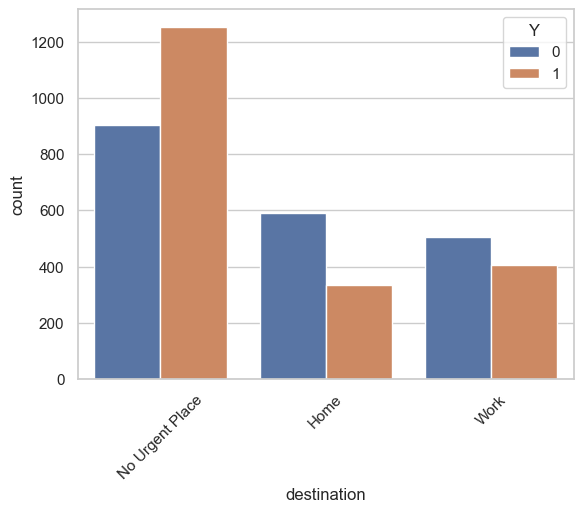

In [23]:
evaluate_cc_acceptance(coffee_coupons, 'destination')

This shows that about a drivers with no urgent destination were most likely to accept a coupon, folled by drivers going to work. Only about a third of drivers headed home accepted the coupon.

**Evaluate by time of day**

Let's look at coupons offered by time of day, and their aceptance rates.

For time == 10AM:
    899 coupons were offered
     64.07% of coupons were accepted
For time == 2PM:
    794 coupons were offered
     54.79% of coupons were accepted
For time == 6PM:
    1093 coupons were offered
     41.26% of coupons were accepted
For time == 7AM:
    913 coupons were offered
     44.58% of coupons were accepted
For time == 10PM:
    297 coupons were offered
     42.42% of coupons were accepted


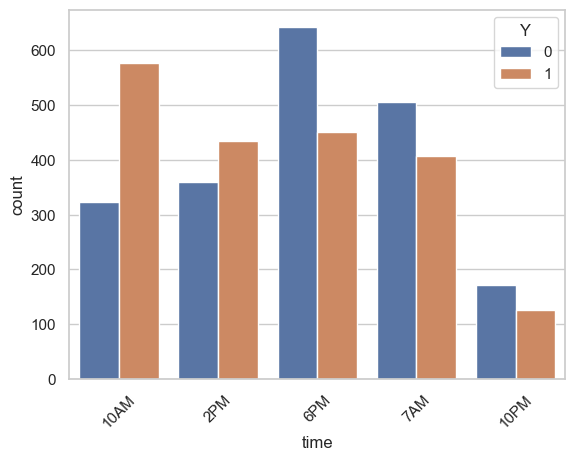

In [24]:
evaluate_cc_acceptance(coffee_coupons, 'time')

We can see that drivers at 10AM and 2PM were the most likely to accept coffee coupons. Drivers at other times were only 40-45% likely to accept the coupon.

**Evaluate by Coffee House visits**

Let's look at the breakdown based on how often drivers visited Coffee Houses in the past.

For CoffeeHouse == never:
    927 coupons were offered
     18.88% of coupons were accepted
For CoffeeHouse == less1:
    1075 coupons were offered
     48.19% of coupons were accepted
For CoffeeHouse == 4~8:
    538 coupons were offered
     68.59% of coupons were accepted
For CoffeeHouse == 1~3:
    1042 coupons were offered
     64.78% of coupons were accepted
For CoffeeHouse == gt8:
    342 coupons were offered
     65.79% of coupons were accepted
For CoffeeHouse == nan:
    0 coupons were offered
     nan% of coupons were accepted


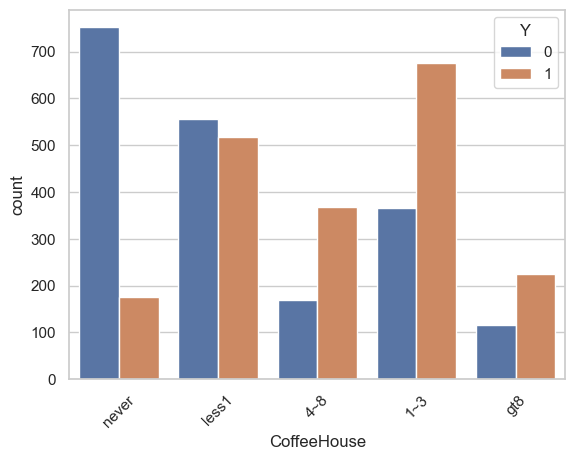

In [25]:
evaluate_cc_acceptance(coffee_coupons, 'CoffeeHouse')

We can clearly see that drivers that frequented Coffee Houses 1 or more times accepted coffee coupons about two-thirds of the time.

**Evaluate compond conditions**

Given that there is a clear preference based on Coffee House visits, let's see if we can identify other categories to narrow down ideal recipients.

For expiration == 2h:
    2227 coupons were offered
     43.20% of coupons were accepted
For expiration == 1d:
    1769 coupons were offered
     58.39% of coupons were accepted


Text(0.5, 1.0, 'Drivers who visit Coffee Houses more than once')

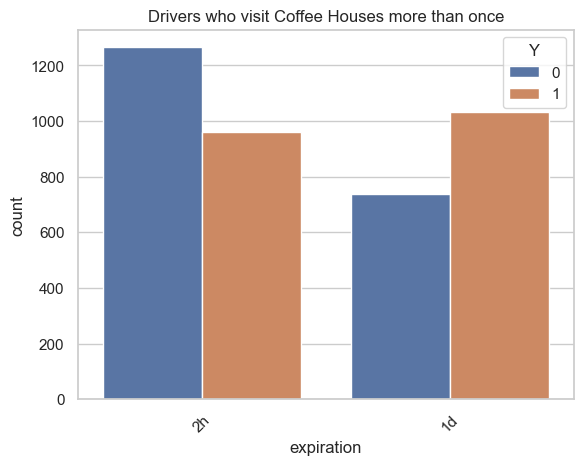

In [26]:
evaluate_cc_acceptance(coffee_coupons, 'expiration')
plt.title('Drivers who visit Coffee Houses more than once')

We can see that the acceptance rate is higher in cases where the coupon as a longer expiration, suggesting that drivers are more likely to accept if they can use the coupon the following day.

For temperature == 80:
    2401 coupons were offered
     52.98% of coupons were accepted
For temperature == 55:
    1277 coupons were offered
     45.58% of coupons were accepted
For temperature == 30:
    318 coupons were offered
     44.34% of coupons were accepted


Text(0.5, 1.0, 'Drivers who visit Coffee Houses more than once')

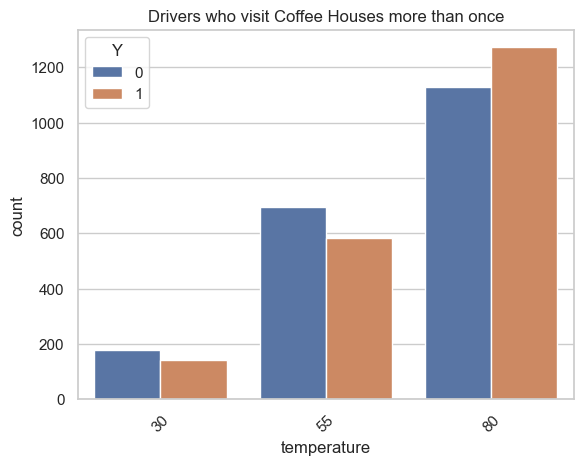

In [27]:
evaluate_cc_acceptance(coffee_coupons, 'temperature')
plt.title('Drivers who visit Coffee Houses more than once')

There is a slightly higher preference to accept coupons when the temperature is warm.

**Compound Evaluation**

Let's look at drivers who visit Coffee Houses more than once, on a warm day compared to other drivers.

In [28]:
one_or_more_visits = coffee_coupons['CoffeeHouse'].isin(['1~3', '4~8', 'gt8'])
warm_day = coffee_coupons['temperature'] == 80

condition = one_or_more_visits & warm_day

print_cc_acceptance(coffee_coupons, condition, 'frequent visitors on a warm day')
print_cc_acceptance(coffee_coupons, ~condition, 'others')

For frequent visitors on a warm day:
    1139 coupons were offered
     71.64% of coupons were accepted
For others:
    2857 coupons were offered
     41.27% of coupons were accepted


**Hypothesis**

Drivers who go to Coffee Houses more than once, are about 66% likely to accept Coffee House coupons. Offering these coupons on a hot day increases the acceptance rate to over 70%. Drivers that do not fall into this category *(frequent vistors + warm day)* are only about 40% likely to accept the coupon.

### Recommendation

To maximize the acceptance of Coffee House coupons, it would be most effective to offer them to drivers who frequently visit CoffeeHouses on days that are warm. This will also help reduce the negative sentiment experienced by drivers when they are offered coupons they are less likely to accept.

Using a similar approach for the other coupon types can help us refine when we offer these coupons to maximize user happiness, while also reducing "coupon fatigue" where they are offered coupons they are unlikely to accept.